In [1]:
import nmrstarlib
from pybmrb import ChemicalShift
import pandas as pd
from pylab import *
import glob

In [2]:
# The bmrb ID for biris 2012 rhesus chemical shifts
bmrb_id = 18097

# Use pybmrb to fetch and parse the chemical shift data from bmrbm
bmrb_data = ChemicalShift.from_bmrb(bmrb_id)

a=list(bmrb_data[str(bmrb_id)+"-1"].values())[0]
a.pop("seq_ids") # we don't need the sequence IDs and it interferes with our easy conversion to a DF

#Convert the bmrb data to a dataframe
bmrbDF=pd.DataFrame.from_records(
    [
        (level1,level2, leaf)
        for level1, level2Dict in a.items()
        for level2, leaf in level2Dict.items()
        #for level3, leaf in level3Dict.items()
    ],
    columns=['resnum', 'atom',"TheList"]
)

# Unpack the list column in our dataframe
bmrbDF["resname"] = bmrbDF["TheList"].apply(lambda x: x[0])
bmrbDF["shift"] = bmrbDF["TheList"].apply(lambda x: x[-1])
bmrbDF["rescode"] = bmrbDF["TheList"].apply(lambda x: x[1])
bmrbDF["resid"] = bmrbDF['resnum'] +287 # The resnums appear to be 287 behind the resids.
bmrbDF["uniqueID"] = bmrbDF["resid"].astype(str) + bmrbDF["rescode"] + bmrbDF["atom"]

INFO:numexpr.utils:NumExpr defaulting to 8 threads.


In [3]:
testFile = pd.read_csv("shiftx/from-narval/s1_t0_f0.pdb.cs")
testFile['uniqueID'] = testFile.NUM.astype(str) + testFile.RES + testFile.ATOMNAME
testFile

,NUM,RES,ATOMNAME,SHIFT,uniqueID
0,290,E,C,177.5854,290EC
1,290,E,CA,59.3527,290ECA
2,290,E,CB,29.6186,290ECB
3,290,E,CD,182.5198,290ECD
4,290,E,CG,36.5211,290ECG
...,...,...,...,...,...
2490,493,P,HB3,1.8068,493PHB3
2491,493,P,HD2,2.9385,493PHD2
2492,493,P,HD3,3.0524,493PHD3
2493,493,P,HG2,1.6556,493PHG2


In [4]:
#allrhesus_csv = glob.glob("shiftx/from-narval/s1*.cs")
#all_shiftx_shifts=[]
#all_shiftx_dfs=[]
#all_uniqueIds=[]
#for i in range(len(allrhesus_csv)):
#    d = pd.read_csv(allrhesus_csv[i])
#    d['uniqueID'] = d.NUM.astype(str) + d.RES + d.ATOMNAME
#    uniqueIds+=list(d.uniqueID.values)
#    all_shiftx_dfs.append(d)
#    all_shiftx_shifts.append(d.SHIFT)
#unique_Ids=sorted(set(uniqueIds))

In [5]:
#combined_bmrb_andTestshiftx=bmrbHshifts.set_index('uniqueID').join(testHshifts.set_index('uniqueID'))
#combined_bmrb_andTestshiftx=combined_bmrb_andTestshiftx.dropna()
#combined_bmrb_andTestshiftx
#
#
#testHshifts=testFile[testFile["ATOMNAME"]=="H"]
#bmrbHshifts=bmrbDF[bmrbDF["atom"] == 'H']
#plot(bmrbHshifts.resid,bmrbHshifts['shift'],"o")
#plot(testHshifts.NUM,testHshifts['SHIFT'],"o")
#
#show()
#plot(combined_bmrb_andTestshiftx['shift'],combined_bmrb_andTestshiftx["SHIFT"],'o')
#ylabel("SHIFTX")
#xlabel("BMRB")

Text(0.5, 0, 'BMRB')

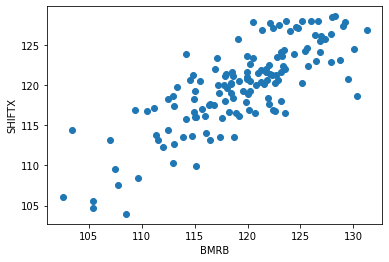

In [6]:

#OK, next, we need to apply this for all atoms.


combined_bmrb_andTestshiftx=bmrbDF.set_index('uniqueID').join(testFile.set_index('uniqueID'))
combined_bmrb_andTestshiftx=combined_bmrb_andTestshiftx.dropna()
combined_bmrb_andTestshiftx

show()
plot(combined_bmrb_andTestshiftx.query("ATOMNAME == 'N'")['shift'],combined_bmrb_andTestshiftx.query("ATOMNAME == 'N'")["SHIFT"],'o')
ylabel("SHIFTX")
xlabel("BMRB")

In [7]:
# Let's restore the NANs and set the SHIFTS column to 0, then loop over and add to the shifts
combined_bmrb_andTestshiftx=bmrbDF.set_index('uniqueID').join(testFile.set_index('uniqueID'))
combined_bmrb_andTestshiftx["SHIFT"] = 0

# we will also need a column to count the number of times a shift value was summed/meaned over, since it might not be the same number of times for each atom
combined_bmrb_andTestshiftx["NCOUNTED"] = 0 #Basically, if the column isnan() for each frame, we'll subtract that number off when taking the mean and stdev



allrhesus_csv = glob.glob("shiftx/from-narval/s1*.cs")
rhesusbytrj=[]
for i in range(9):
    thistrjfiles = glob.glob(f"shiftx/from-narval/s1_t{i}_*.cs")
    rhesusbytrj.append(thistrjfiles)
    
    


def computeCS(experimentalDF,csFiles):    
    testFile = pd.read_csv(csFiles[0])
    testFile['uniqueID'] = testFile.NUM.astype(str) + testFile.RES + testFile.ATOMNAME
    combined_bmrb_andTestshiftx=experimentalDF.set_index('uniqueID').join(testFile.set_index('uniqueID'))
    combined_bmrb_andTestshiftx["SHIFT"] = 0

    # we will also need a column to count the number of times a shift value was summed/meaned over, since it might not be the same number of times for each atom
    combined_bmrb_andTestshiftx["NCOUNTED"] = 0 #Basically, if the column isnan() for each frame, we'll subtract that number off when taking the mean and stdev

    for i in range(len(csFiles)):

        # Read in data
        shiftxdf = pd.read_csv(csFiles[i])

        #First thing is to include the uniqueID
        shiftxdf['uniqueID'] = shiftxdf.NUM.astype(str) + shiftxdf.RES + shiftxdf.ATOMNAME

        #Next we left join the current frame onto the main frame to exclude all data that is not present in the BMRB
        currentFrameJoin=combined_bmrb_andTestshiftx.join(shiftxdf.set_index("uniqueID")["SHIFT"],rsuffix='new')

        # Increase the count of counted atoms - we are summing over shifts in each file, but we need to remember how many files we summed over for each atom
        combined_bmrb_andTestshiftx["NCOUNTED"]+=~combined_bmrb_andTestshiftx.join(shiftxdf.set_index("uniqueID")["SHIFT"],rsuffix='new').SHIFTnew.isna()

        #Add the shifts that we have to the "SHIFT" columnn
        combined_bmrb_andTestshiftx["SHIFT"]+=currentFrameJoin["SHIFTnew"].fillna(0)

    # Once it is all done, we jsut need to divide the shifts by the NUMCOUNTED to get the mean shifts over frames
    combined_bmrb_andTestshiftx["SHIFT"]/=combined_bmrb_andTestshiftx["NCOUNTED"]


    combined_bmrb_andTestshiftx["SD"] = 0 #Basically, if the column isnan() for each frame, we'll subtract that number off when taking the mean and stdev


    for i in range(len(csFiles)):

        # Read in data
        shiftxdf = pd.read_csv(allrhesus_csv[i])

        #First thing is to include the uniqueID
        shiftxdf['uniqueID'] = shiftxdf.NUM.astype(str) + shiftxdf.RES + shiftxdf.ATOMNAME

        #Next we left join the current frame onto the main frame to exclude all data that is not present in the BMRB
        currentFrameJoin=combined_bmrb_andTestshiftx.join(shiftxdf.set_index("uniqueID")["SHIFT"],rsuffix='new')

        #Add the shifts that we have to the "SHIFT" columnn
        combined_bmrb_andTestshiftx["SD"]+=(currentFrameJoin["SHIFTnew"].fillna(0) - currentFrameJoin["SHIFT"])**2

    combined_bmrb_andTestshiftx["SD"]/=combined_bmrb_andTestshiftx["NCOUNTED"]
    combined_bmrb_andTestshiftx["SD"] = sqrt(combined_bmrb_andTestshiftx["SD"])
    
    
    return combined_bmrb_andTestshiftx

In [8]:
all_combined_bmrb_and_simulalted_shiftx=[]
all_simulatedshifts=[]

for i in range(len(rhesusbytrj)):
    all_combined_bmrb_and_simulalted_shiftx.append(computeCS(bmrbDF,rhesusbytrj[i]))

    



In [9]:
all_combined_bmrb_and_simulalted_shiftx[0]


,resnum,atom,TheList,resname,shift,rescode,resid,NUM,RES,ATOMNAME,SHIFT,NCOUNTED,SD
uniqueID,,,,,,,,,,,,,
290EH,3,H,"[GLU, E, 8.831]",GLU,8.831,E,290,290.0,E,H,8.562341,401,0.107686
290EHA,3,HA,"[GLU, E, 3.992]",GLU,3.992,E,290,290.0,E,HA,4.068313,401,0.121019
290EC,3,C,"[GLU, E, 178.218]",GLU,178.218,E,290,290.0,E,C,176.951768,401,0.491606
290ECA,3,CA,"[GLU, E, 58.828]",GLU,58.828,E,290,290.0,E,CA,56.854330,401,1.457182
290EN,3,N,"[GLU, E, 122.345]",GLU,122.345,E,290,290.0,E,N,121.650876,401,0.608654
...,...,...,...,...,...,...,...,...,...,...,...,...,...
494SN,207,N,"[SER, S, 115.376]",SER,115.376,S,494,NaN,NaN,NaN,NaN,0,NaN
495SH,208,H,"[SER, S, 7.725]",SER,7.725,S,495,NaN,NaN,NaN,NaN,0,NaN
495SC,208,C,"[SER, S, 178.543]",SER,178.543,S,495,NaN,NaN,NaN,NaN,0,NaN


In [10]:
shifts_byexp_and_bytrj=pd.DataFrame()
shifts_byexp_and_bytrj["uniqueID"] = all_combined_bmrb_and_simulalted_shiftx[0].index
shifts_byexp_and_bytrj["atomname"] = all_combined_bmrb_and_simulalted_shiftx[0].atom.values
shifts_byexp_and_bytrj["resid"] = all_combined_bmrb_and_simulalted_shiftx[0].resid.values
shifts_byexp_and_bytrj["recode"] = all_combined_bmrb_and_simulalted_shiftx[0].rescode.values
shifts_byexp_and_bytrj["resname"] = all_combined_bmrb_and_simulalted_shiftx[0].resname.values
shifts_byexp_and_bytrj["shift_exp"] = all_combined_bmrb_and_simulalted_shiftx[0]["shift"].values
shifts_byexp_and_bytrj["shift_sim_avg"] = 0
for i in range(len(all_combined_bmrb_and_simulalted_shiftx)):
    shifts_byexp_and_bytrj[f"shift_sim_{i}"] = all_combined_bmrb_and_simulalted_shiftx[i].SHIFT.values
    shifts_byexp_and_bytrj["shift_sim_avg"]+=all_combined_bmrb_and_simulalted_shiftx[i].SHIFT.values
shifts_byexp_and_bytrj["shift_sim_avg"] /=len(all_combined_bmrb_and_simulalted_shiftx)



In [11]:
shifts_byexp_and_bytrj['shift_sim_sem']=shifts_byexp_and_bytrj[['shift_sim_0',
                                                                'shift_sim_1',
                                                                'shift_sim_2',
                                                                'shift_sim_3',
                                                                'shift_sim_4',
                                                                'shift_sim_5',
                                                                'shift_sim_6',
                                                                'shift_sim_7',
                                                                'shift_sim_8']].sem(axis = 1)

In [12]:
shifts_byexp_and_bytrj

,uniqueID,atomname,resid,recode,resname,shift_exp,shift_sim_avg,shift_sim_0,shift_sim_1,shift_sim_2,shift_sim_3,shift_sim_4,shift_sim_5,shift_sim_6,shift_sim_7,shift_sim_8,shift_sim_sem
0,290EH,H,290,E,GLU,8.831,8.632379,8.562341,8.622272,8.584601,8.645952,8.688546,8.678820,8.670422,8.606087,8.632370,0.014397
1,290EHA,HA,290,E,GLU,3.992,4.035759,4.068313,4.011365,4.023756,4.038180,4.010124,3.992127,4.034148,4.110390,4.033427,0.011752
2,290EC,C,290,E,GLU,178.218,177.275784,176.951768,177.263952,177.065346,177.403951,177.436542,177.514386,177.397922,177.206923,177.241263,0.061176
3,290ECA,CA,290,E,GLU,58.828,57.989341,56.854330,57.907778,57.145106,58.281226,58.768258,58.853735,58.557140,57.638474,57.898021,0.232754
4,290EN,N,290,E,GLU,122.345,121.262328,121.650876,121.246197,121.464670,121.190134,121.030719,120.963248,121.156879,121.362033,121.296193,0.070974
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
805,494SN,N,494,S,SER,115.376,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
806,495SH,H,495,S,SER,7.725,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
807,495SC,C,495,S,SER,178.543,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
808,495SCA,CA,495,S,SER,59.871,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN


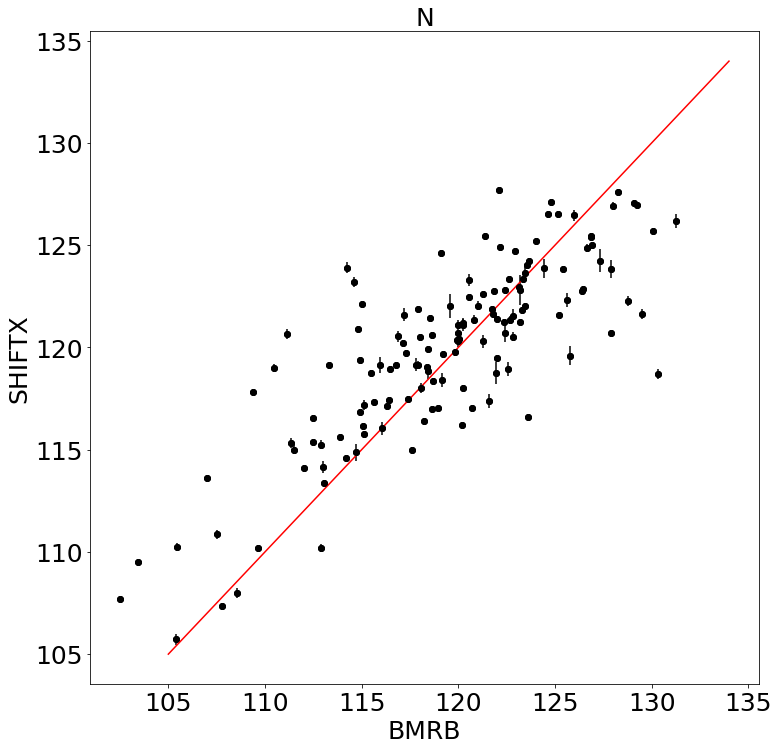

In [13]:
figure(figsize = (12,12))
plot(shifts_byexp_and_bytrj.query("atomname == 'N'")['shift_exp'],shifts_byexp_and_bytrj.query("atomname == 'N'")["shift_sim_avg"],'o',color = 'black')
errorbar(shifts_byexp_and_bytrj.query("atomname == 'N'")['shift_exp'],shifts_byexp_and_bytrj.query("atomname == 'N'")["shift_sim_avg"],yerr=shifts_byexp_and_bytrj.query("atomname == 'N'")["shift_sim_sem"],fmt="o",color = 'black')

ylabel("SHIFTX",fontsize = 25)
xlabel("BMRB",fontsize = 25)
title('N',fontsize = 25)
_=xticks(fontsize = 25)
_=yticks(fontsize = 25)
plot(arange(105,135),arange(105,135),color = 'red')

KeyError: 'SD'

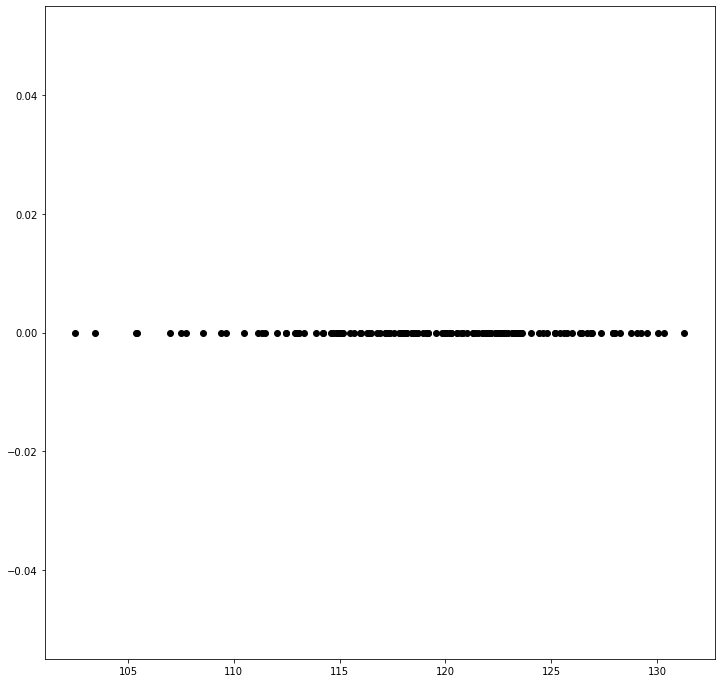

In [14]:
figure(figsize = (12,12))
plot(combined_bmrb_andTestshiftx.query("ATOMNAME == 'N'")['shift'],combined_bmrb_andTestshiftx.query("ATOMNAME == 'N'")["SHIFT"],'o',color = 'black')
errorbar(combined_bmrb_andTestshiftx.query("ATOMNAME == 'N'")['shift'],combined_bmrb_andTestshiftx.query("ATOMNAME == 'N'")["SHIFT"],yerr=combined_bmrb_andTestshiftx.query("ATOMNAME == 'N'")["SD"],fmt="o",color = 'black')

ylabel("SHIFTX",fontsize = 25)
xlabel("BMRB",fontsize = 25)
title('N',fontsize = 25)
_=xticks(fontsize = 25)
_=yticks(fontsize = 25)
plot(arange(105,135),arange(105,135),color = 'red')

KeyError: 'SD'

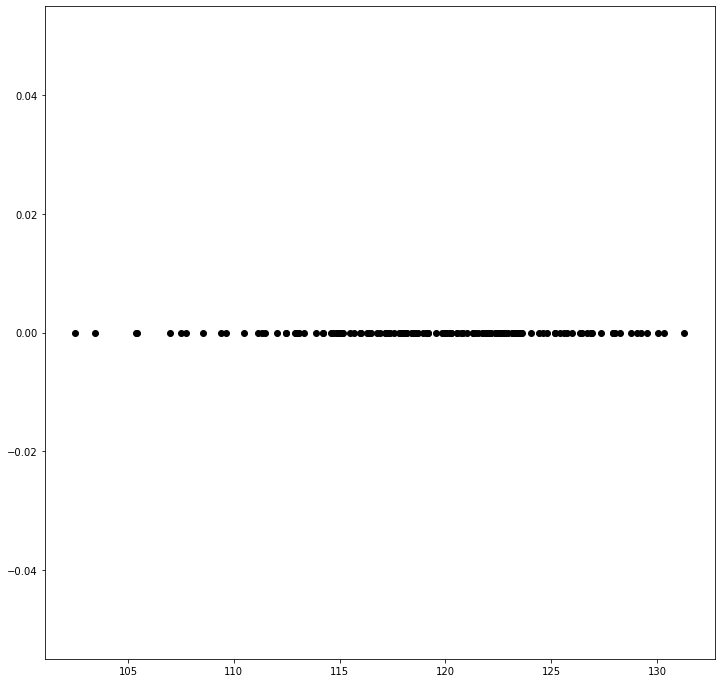

In [15]:
figure(figsize = (12,12))
plot(combined_bmrb_andTestshiftx.query("ATOMNAME == 'N'")['shift'],combined_bmrb_andTestshiftx.query("ATOMNAME == 'N'")["SHIFT"],'o',color = 'black')
errorbar(combined_bmrb_andTestshiftx.query("ATOMNAME == 'N'")['shift'],combined_bmrb_andTestshiftx.query("ATOMNAME == 'N'")["SHIFT"],yerr=combined_bmrb_andTestshiftx.query("ATOMNAME == 'N'")["SD"],fmt="o",color = 'black')

ylabel("SHIFTX",fontsize = 25)
xlabel("BMRB",fontsize = 25)
title('N',fontsize = 25)
_=xticks(fontsize = 25)
_=yticks(fontsize = 25)
plot(arange(105,135),arange(105,135),color = 'red')


KeyError: 'SD'

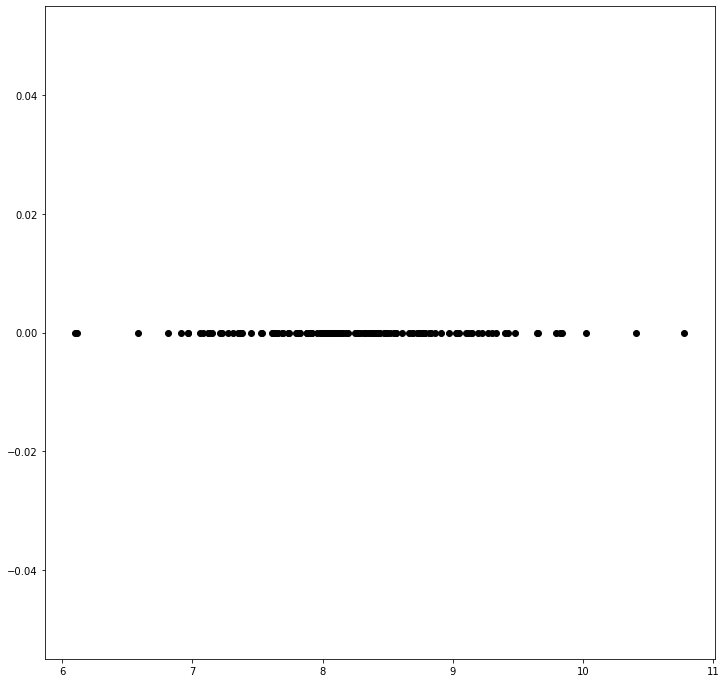

In [16]:
figure(figsize = (12,12,))
plot(combined_bmrb_andTestshiftx.query("ATOMNAME == 'H'")['shift'],combined_bmrb_andTestshiftx.query("ATOMNAME == 'H'")["SHIFT"],'o',color = 'black')
errorbar(combined_bmrb_andTestshiftx.query("ATOMNAME == 'H'")['shift'],combined_bmrb_andTestshiftx.query("ATOMNAME == 'H'")["SHIFT"],yerr=combined_bmrb_andTestshiftx.query("ATOMNAME == 'H'")["SD"],fmt="o",color = 'black')

plot(arange(6,12),arange(6,12),color = 'red')
ylabel("SHIFTX",fontsize = 25)
xlabel("BMRB",fontsize = 25)
title('H',fontsize = 25)
_=xticks(fontsize = 25)
_=yticks(fontsize = 25)

Text(0, 0.5, 'Chemical Shifft (ppm)')

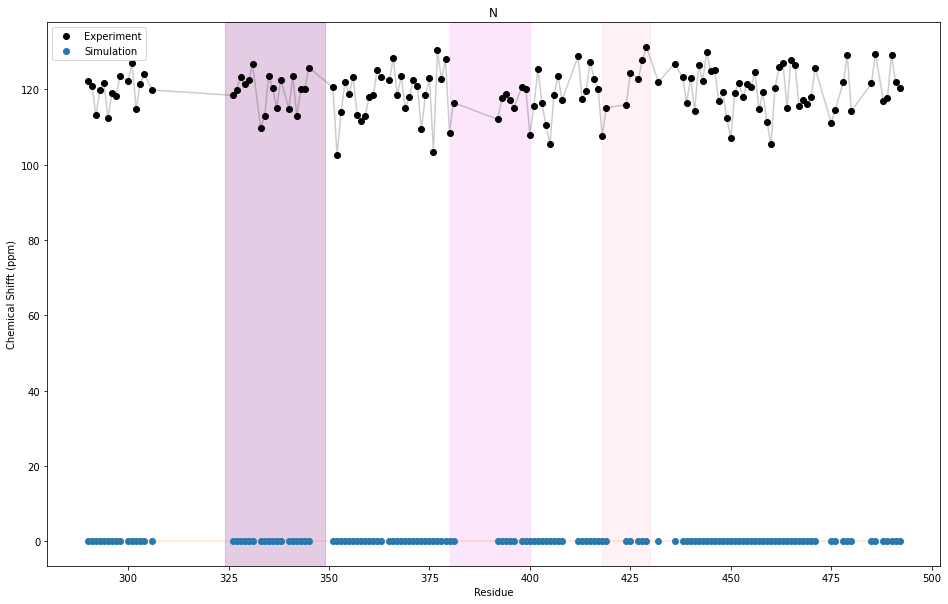

In [17]:
figure(figsize = (16,10))
plot(combined_bmrb_andTestshiftx.query("ATOMNAME == 'N'")['NUM'],combined_bmrb_andTestshiftx.query("ATOMNAME == 'N'")['shift'],"o",color = 'black',label = "Experiment")
plot(combined_bmrb_andTestshiftx.query("ATOMNAME == 'N'")['NUM'],combined_bmrb_andTestshiftx.query("ATOMNAME == 'N'")['SHIFT'],"o",label = "Simulation")

plot(combined_bmrb_andTestshiftx.query("ATOMNAME == 'N'")['NUM'],combined_bmrb_andTestshiftx.query("ATOMNAME == 'N'")['shift'],alpha = 0.2,color = 'black')
plot(combined_bmrb_andTestshiftx.query("ATOMNAME == 'N'")['NUM'],combined_bmrb_andTestshiftx.query("ATOMNAME == 'N'")['SHIFT'],alpha = 0.2)
legend()


axvspan(324,349,color = "purple", alpha = 0.2)
axvspan(380,400,color = "violet", alpha = 0.2)
axvspan(418,430,color = "pink", alpha = 0.2)

title("N")
xlabel("Residue")
ylabel("Chemical Shifft (ppm)")

Text(0, 0.5, 'Chemical Shifft (ppm)')

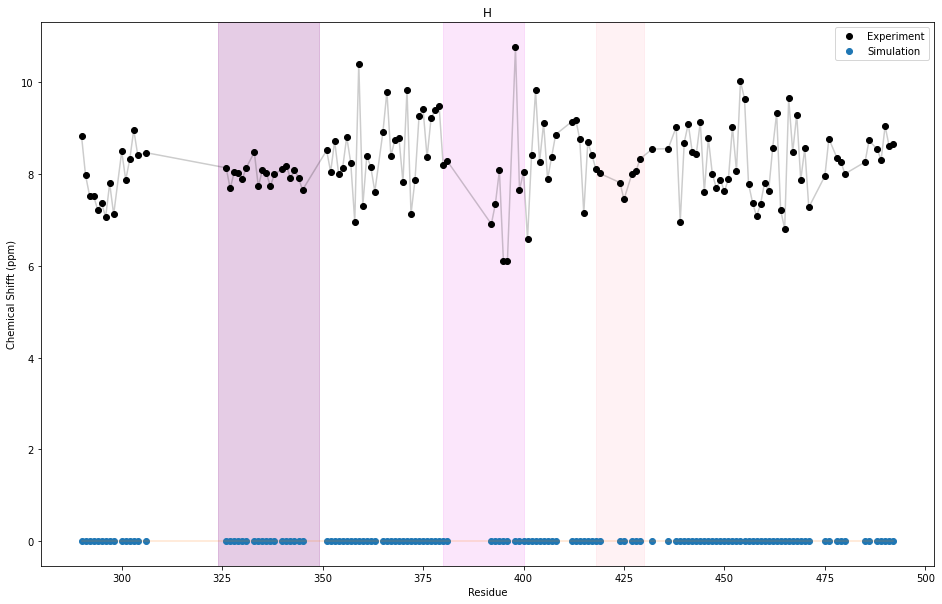

In [18]:
figure(figsize = (16,10))
plot(combined_bmrb_andTestshiftx.query("ATOMNAME == 'H'")['NUM'],combined_bmrb_andTestshiftx.query("ATOMNAME == 'H'")['shift'],"o",color = 'black',label = "Experiment")
plot(combined_bmrb_andTestshiftx.query("ATOMNAME == 'H'")['NUM'],combined_bmrb_andTestshiftx.query("ATOMNAME == 'H'")['SHIFT'],"o",label = "Simulation")

plot(combined_bmrb_andTestshiftx.query("ATOMNAME == 'H'")['NUM'],combined_bmrb_andTestshiftx.query("ATOMNAME == 'H'")['shift'],alpha = 0.2,color = 'black')
plot(combined_bmrb_andTestshiftx.query("ATOMNAME == 'H'")['NUM'],combined_bmrb_andTestshiftx.query("ATOMNAME == 'H'")['SHIFT'],alpha = 0.2)
legend()


axvspan(324,349,color = "purple", alpha = 0.2)
axvspan(380,400,color = "violet", alpha = 0.2)
axvspan(418,430,color = "pink", alpha = 0.2)
        
title("H")
xlabel("Residue")
ylabel("Chemical Shifft (ppm)")